 # Preprocesamiento + vectorización + modelos de ML

1 - Imports

In [9]:
import sys
sys.path.append("../Code")

import pandas as pd
import matplotlib.pyplot as plt
import joblib

from preproc import preprocesamiento

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

2 - Carga de datos

In [11]:
DATA_PATH = "../Data/raw/tcga_simple_train.csv"
df = pd.read_csv(DATA_PATH)

df.head()

,patient_id,text,t
0,TCGA-BP-5195,Date of Recelpt: Clinical Diagnosis & History:...,T1
1,TCGA-D7-8573,"Material: 1) Material: stomach, Method of coll...",T3
2,TCGA-EI-7004,page 1 / 1. copy No. 3. Examination: Histopath...,T4
3,TCGA-EB-A82B,Patient ID: Gross Description: A mass is locat...,T4
4,TCGA-A6-3808,SPECIMEN. Right colon. CLINICAL NOTES. PRE-OP ...,T3


In [12]:
df = df.dropna(subset=["text", "t"]).copy()

df["text"] = df["text"].astype(str)
df["t"] = df["t"].astype(str).str.upper().str.strip()

df["t"].value_counts()

t
T2    1752
T3    1583
T1    1302
T4     521
Name: count, dtype: int64

3 - Generar textos preprocesados

In [14]:
# Genero varias versiones del texto para comparar.
# La idea es ver si el modelo mejora con lematización, filtrado POS, etc.

df["raw_text"] = df["text"]

df["prep_1_lower"] = preprocesamiento(df["text"], id=1)
df["prep_2_lemma"] = preprocesamiento(df["text"], id=2)
df["prep_3_pos"] = preprocesamiento(df["text"], id=3)
df["prep_4_lemma_pos"] = preprocesamiento(df["text"], id=4)

df.head()

,patient_id,text,t,raw_text,prep_1_lower,prep_2_lemma,prep_3_pos,prep_4_lemma_pos
0,TCGA-BP-5195,Date of Recelpt: Clinical Diagnosis & History:...,T1,Date of Recelpt: Clinical Diagnosis & History:...,date recelpt clinical diagnosis history incide...,date recelpt clinical diagnosis history incide...,date recelpt clinical diagnosis history incide...,date recelpt clinical diagnosis history incide...
1,TCGA-D7-8573,"Material: 1) Material: stomach, Method of coll...",T3,"Material: 1) Material: stomach, Method of coll...",material 1 material stomach method collection ...,material 1 material stomach method collection ...,material material stomach method collection le...,material material stomach method collection le...
2,TCGA-EI-7004,page 1 / 1. copy No. 3. Examination: Histopath...,T4,page 1 / 1. copy No. 3. Examination: Histopath...,page 1 1 copy 3 examination histopathological ...,page 1 1 copy 3 examination histopathological ...,page copy examination histopathological examin...,page copy examination histopathological examin...
3,TCGA-EB-A82B,Patient ID: Gross Description: A mass is locat...,T4,Patient ID: Gross Description: A mass is locat...,patient id gross description mass located righ...,patient id gross description mass locate right...,patient id gross description mass located righ...,patient id gross description mass locate right...
4,TCGA-A6-3808,SPECIMEN. Right colon. CLINICAL NOTES. PRE-OP ...,T3,SPECIMEN. Right colon. CLINICAL NOTES. PRE-OP ...,specimen right colon clinical notes pre op dia...,specimen right colon clinical note pre op diag...,specimen right colon clinical notes pre op dia...,specimen right colon clinical note pre op diag...


4 - Train / Validation

In [15]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["t"]
)

print(train_df.shape)
print(val_df.shape)

(4126, 8)
(1032, 8)


In [16]:
y_train = train_df["t"]
y_val = val_df["t"]

5 - Definimos los textos a probar

In [17]:
text_columns = [
    "raw_text",
    "prep_1_lower",
    "prep_2_lemma",
    "prep_3_pos",
    "prep_4_lemma_pos"
]

6 - Vectorizaciones

In [18]:
vectorizers = {
    "bow_binary": CountVectorizer(
        binary=True,
        ngram_range=(1, 2),
        min_df=2
    ),

    "bow_counts": CountVectorizer(
        binary=False,
        ngram_range=(1, 2),
        min_df=2
    ),

    "tfidf_word": TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True
    ),

    "tfidf_char": TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=2,
        sublinear_tf=True
    )
}

7 - Cargamos los modelos de ML clásicos

In [19]:
models = {
    "multinomial_nb": MultinomialNB(),

    "complement_nb": ComplementNB(),

    "logistic_regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "linear_svm": LinearSVC(
        class_weight="balanced",
        random_state=42
    )
}

8 - Ejecutamos nuestros "experimentos"

In [20]:
results = []

best_f1 = 0
best_model = None
best_config = None

for text_col in text_columns:

    X_train = train_df[text_col].fillna("").astype(str)
    X_val = val_df[text_col].fillna("").astype(str)

    for vec_name, vectorizer in vectorizers.items():

        for model_name, model in models.items():

            experiment_name = f"{text_col} + {vec_name} + {model_name}"
            print("Ejecutando:", experiment_name)

            pipeline = Pipeline([
                ("vectorizer", vectorizer),
                ("model", model)
            ])

            pipeline.fit(X_train, y_train)

            y_pred = pipeline.predict(X_val)

            macro_f1 = f1_score(y_val, y_pred, average="macro")
            weighted_f1 = f1_score(y_val, y_pred, average="weighted")

            results.append({
                "experiment": experiment_name,
                "text_column": text_col,
                "vectorizer": vec_name,
                "model": model_name,
                "macro_f1": macro_f1,
                "weighted_f1": weighted_f1
            })

            print("Macro F1:", round(macro_f1, 4))

            if macro_f1 > best_f1:
                best_f1 = macro_f1
                best_model = pipeline
                best_config = {
                    "text_column": text_col,
                    "vectorizer": vec_name,
                    "model": model_name,
                    "macro_f1": macro_f1
                }

Ejecutando: raw_text + bow_binary + multinomial_nb
Macro F1: 0.5402
Ejecutando: raw_text + bow_binary + complement_nb
Macro F1: 0.5327
Ejecutando: raw_text + bow_binary + logistic_regression
Macro F1: 0.7163
Ejecutando: raw_text + bow_binary + linear_svm
Macro F1: 0.679
Ejecutando: raw_text + bow_counts + multinomial_nb
Macro F1: 0.5237
Ejecutando: raw_text + bow_counts + complement_nb
Macro F1: 0.5271
Ejecutando: raw_text + bow_counts + logistic_regression
Macro F1: 0.6685
Ejecutando: raw_text + bow_counts + linear_svm
Macro F1: 0.613
Ejecutando: raw_text + tfidf_word + multinomial_nb
Macro F1: 0.4299
Ejecutando: raw_text + tfidf_word + complement_nb
Macro F1: 0.521
Ejecutando: raw_text + tfidf_word + logistic_regression
Macro F1: 0.6124
Ejecutando: raw_text + tfidf_word + linear_svm
Macro F1: 0.6883
Ejecutando: raw_text + tfidf_char + multinomial_nb
Macro F1: 0.3798
Ejecutando: raw_text + tfidf_char + complement_nb
Macro F1: 0.4515
Ejecutando: raw_text + tfidf_char + logistic_regress

9 - Resultados

In [21]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="macro_f1", ascending=False)

results_df.head(20)

,experiment,text_column,vectorizer,model,macro_f1,weighted_f1
47,prep_2_lemma + tfidf_char + linear_svm,prep_2_lemma,tfidf_char,linear_svm,0.747467,0.758444
79,prep_4_lemma_pos + tfidf_char + linear_svm,prep_4_lemma_pos,tfidf_char,linear_svm,0.744699,0.754795
63,prep_3_pos + tfidf_char + linear_svm,prep_3_pos,tfidf_char,linear_svm,0.738498,0.750709
31,prep_1_lower + tfidf_char + linear_svm,prep_1_lower,tfidf_char,linear_svm,0.735094,0.751484
66,prep_4_lemma_pos + bow_binary + logistic_regre...,prep_4_lemma_pos,bow_binary,logistic_regression,0.718072,0.737126
18,prep_1_lower + bow_binary + logistic_regression,prep_1_lower,bow_binary,logistic_regression,0.716470,0.734265
2,raw_text + bow_binary + logistic_regression,raw_text,bow_binary,logistic_regression,0.716313,0.732745
15,raw_text + tfidf_char + linear_svm,raw_text,tfidf_char,linear_svm,0.715458,0.730953
34,prep_2_lemma + bow_binary + logistic_regression,prep_2_lemma,bow_binary,logistic_regression,0.711596,0.730025
50,prep_3_pos + bow_binary + logistic_regression,prep_3_pos,bow_binary,logistic_regression,0.706415,0.726440


In [22]:
results_df.to_csv("../Results/resultados_ml_clasicos.csv", index=False)

10 - Grafico sencillo

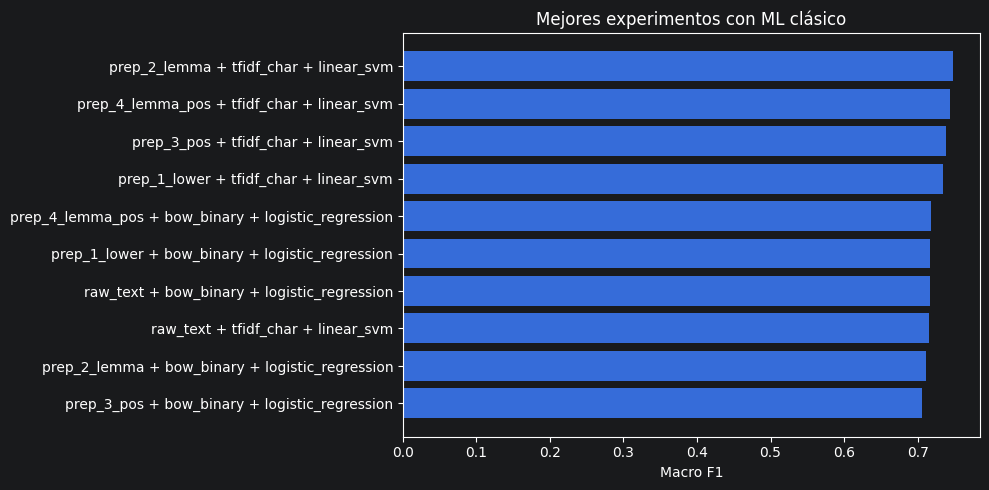

In [23]:
top = results_df.head(10)

plt.figure(figsize=(10, 5))
plt.barh(top["experiment"], top["macro_f1"])
plt.xlabel("Macro F1")
plt.title("Mejores experimentos con ML clásico")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

11 - Evaluación del mejor modelo

In [24]:
best_config

{'text_column': 'prep_2_lemma',
 'vectorizer': 'tfidf_char',
 'model': 'linear_svm',
 'macro_f1': 0.7474672795800328}

In [25]:
best_text_col = best_config["text_column"]

X_val_best = val_df[best_text_col].fillna("").astype(str)

y_pred_best = best_model.predict(X_val_best)

print(classification_report(y_val, y_pred_best))

              precision    recall  f1-score   support

          T1       0.76      0.79      0.77       260
          T2       0.77      0.77      0.77       351
          T3       0.78      0.77      0.77       317
          T4       0.72      0.65      0.69       104

    accuracy                           0.76      1032
   macro avg       0.76      0.75      0.75      1032
weighted avg       0.76      0.76      0.76      1032



12 - Matriz de confusion

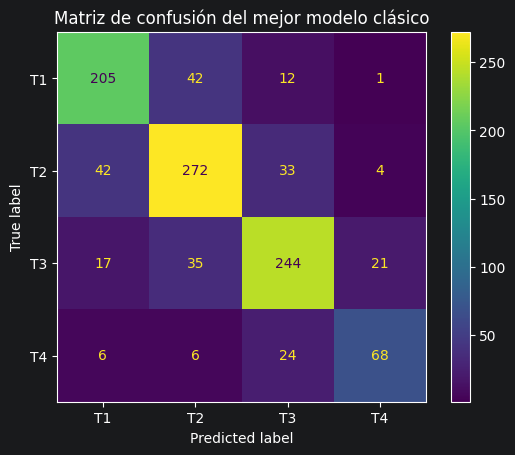

In [26]:
labels = sorted(df["t"].unique())

cm = confusion_matrix(y_val, y_pred_best, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()
plt.title("Matriz de confusión del mejor modelo clásico")
plt.show()